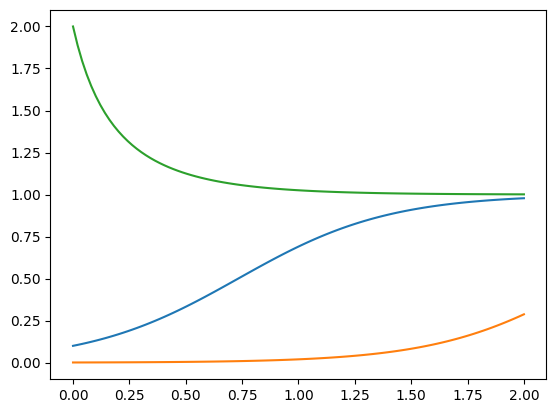

In [1]:
import numpy as np
from matplotlib import pyplot as plt

def f(x,u,lambda0=3.,lambda1=1.):
    return lambda0 * u * (1. - u / lambda1)

def u(x,lambda0=3.,lambda1=1., u0=0.1):
    return lambda1 * np.exp(lambda0 * x) * u0 / (lambda1 + u0 * (np.exp(lambda0 * x) - 1))

x = np.linspace(0,2,100)
y = u(x)
y2 = u(x, u0=1e-3)
y3 = u(x, u0=2.)

plt.figure()
plt.plot(x,y, label="$g_0=0.1$")
plt.plot(x,y2,label="$g_0=0.001$")
plt.plot(x,y3,label="$g_0=2.0")
plt.show()

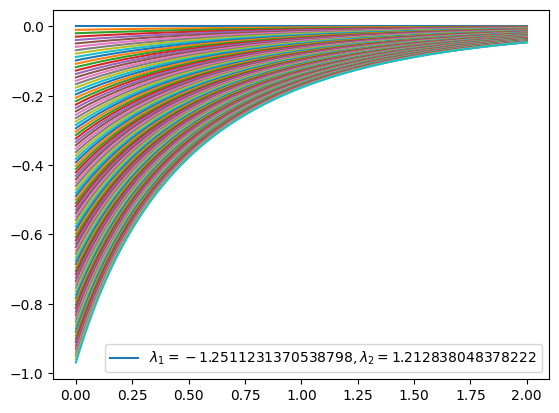

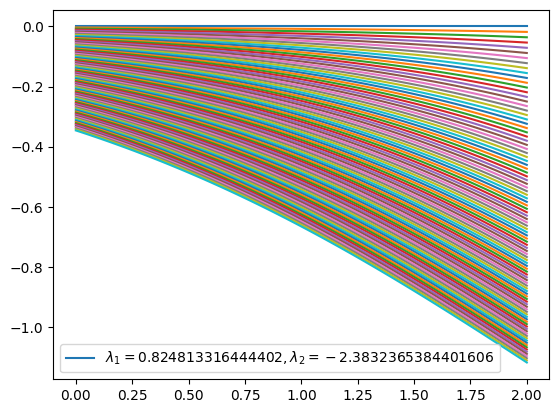

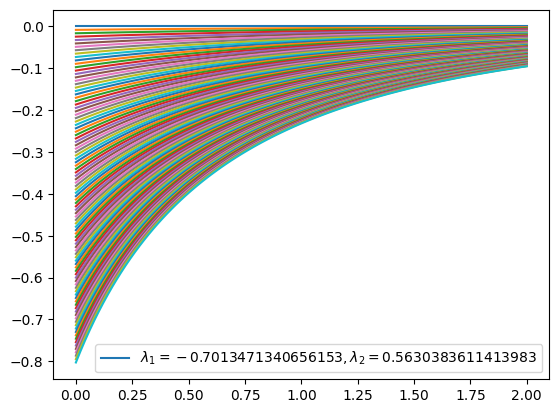

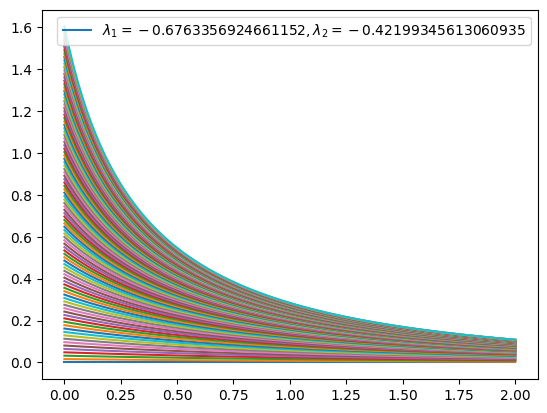

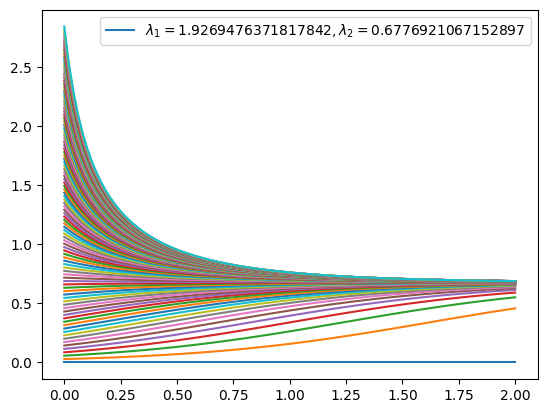

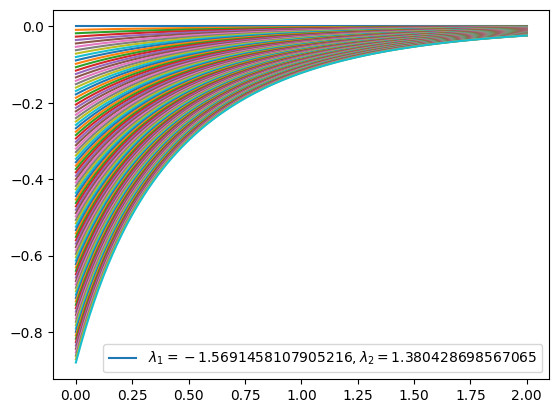

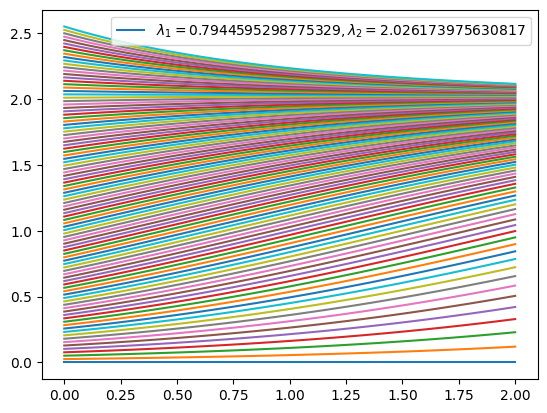

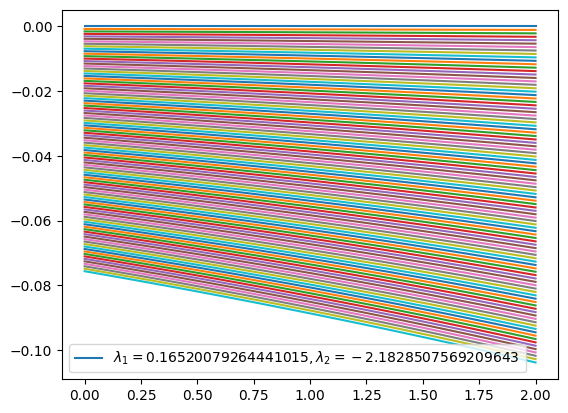

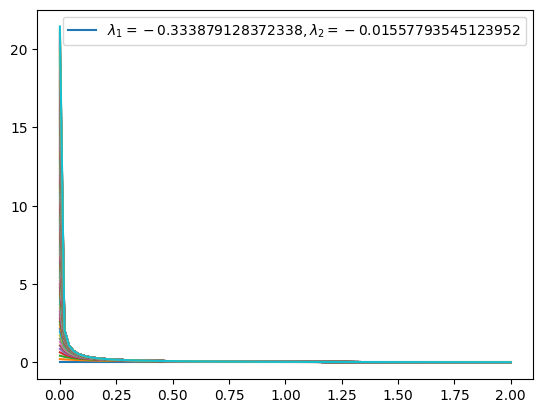

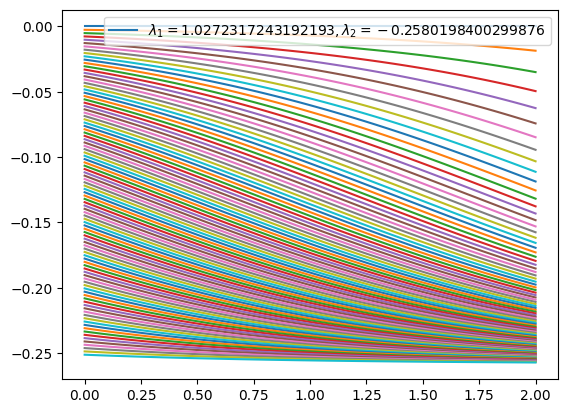

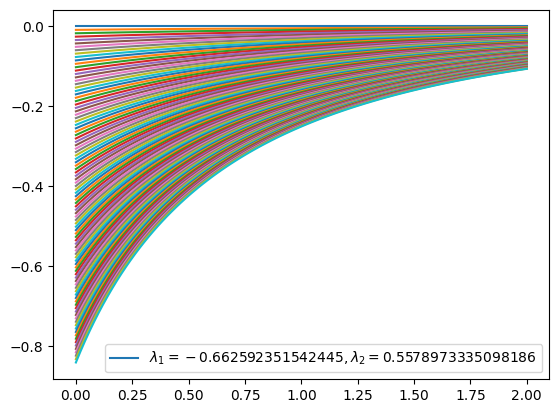

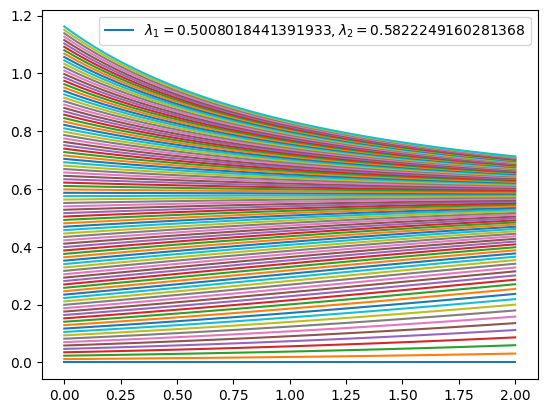

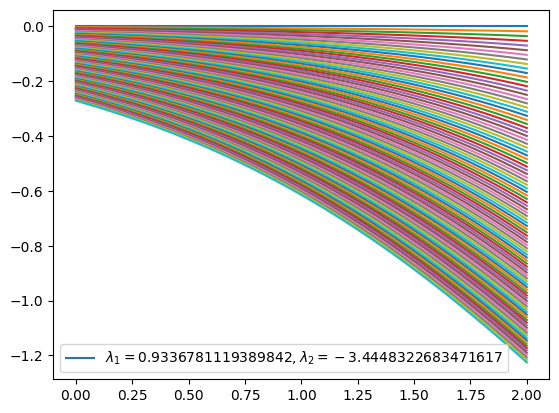

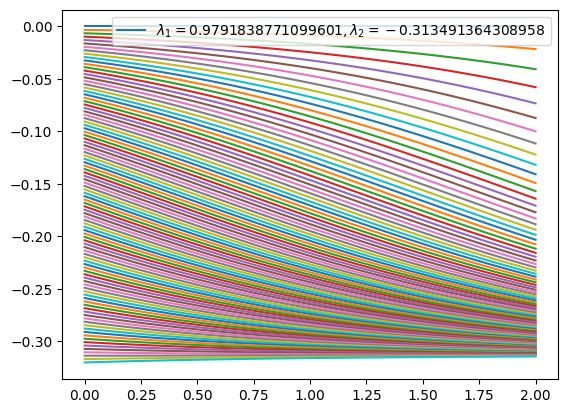

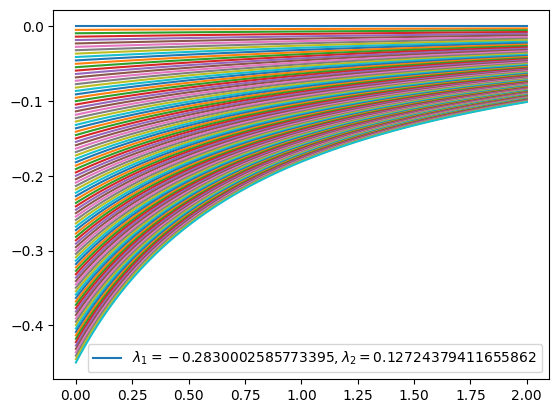

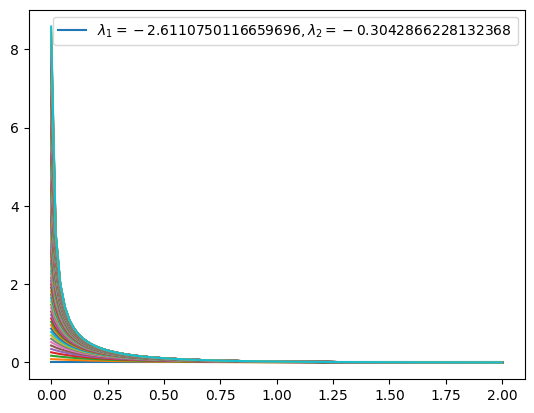

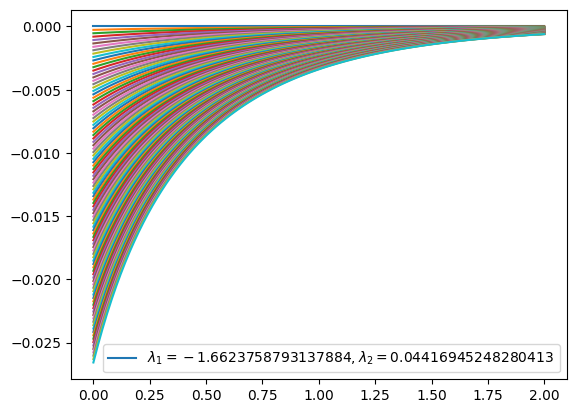

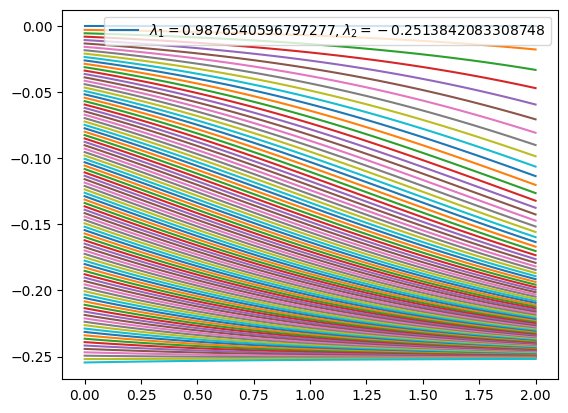

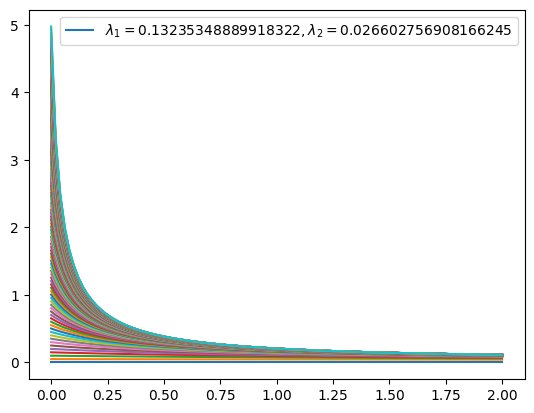

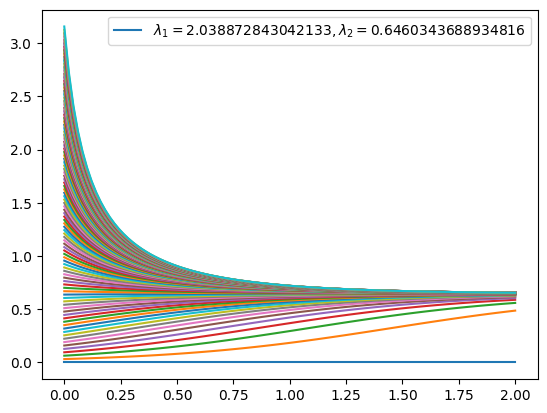

In [2]:
def f(x,u,lambda0=3.,lambda1=1.):
    return lambda0 * u * (1. - u / lambda1)

def u(x,lambda0=3.,lambda1=1., u0=0.1):
    return lambda1 * np.exp(lambda0 * x) * u0 / (lambda1 + u0 * (np.exp(lambda0 * x) - 1))


x = np.linspace(0,2,100)
params = np.random.randn(20, 2)

for (lambda0, lambda1) in params:
    plt.figure()
    for g in np.linspace(0, max(lambda1/lambda0,lambda0/lambda1), 100):
        y = u(x, lambda0=lambda0, lambda1=lambda1, u0=g)    
        plt.plot(x,y)
    plt.legend([f'$\lambda_1 = {lambda0}, \lambda_2 = {lambda1}$'])
    plt.show()


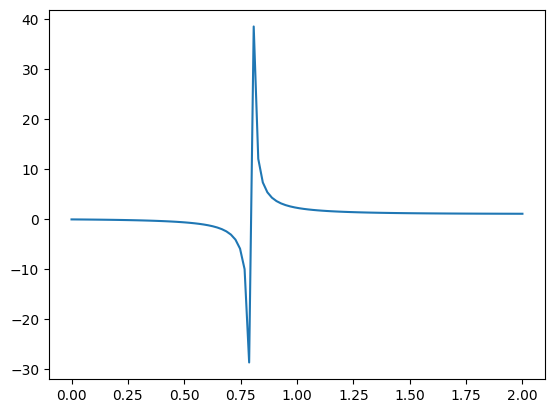

In [3]:
x = np.linspace(0,2,100)
y = u(x, u0=-0.1)

plt.figure()
plt.plot(x,y, label="$g_0=-0.1$")
plt.show()

[[ 1.10855471e-03 -2.89544069e-01]
 [-1.11606630e+00 -1.28827567e-02]
 [-3.78361464e-01 -4.81135363e-01]
 [-1.51733118e+00 -4.90871981e-01]
 [-2.40680579e-01 -6.47947460e-01]
 [ 6.35891080e-01  1.74011731e+00]
 [ 2.96682218e-01  7.07503662e-01]
 [ 1.82281576e+00  4.30769029e-01]
 [ 1.54272963e+00 -9.00721171e-01]
 [-1.37125010e-01  1.29757901e+00]
 [ 6.75271167e-01  3.19581170e-02]
 [ 9.18145896e-01  3.80509466e-01]
 [ 5.16367487e-01 -3.55239458e-01]
 [ 2.08777001e-01  3.28411076e-01]
 [-4.98224766e-01 -2.09177677e+00]
 [-8.25877406e-02  2.45518265e+00]
 [-2.67211000e+00 -9.13279281e-01]
 [-2.27314357e-01  2.69315377e-01]
 [ 1.13046126e+00  1.04239745e+00]
 [ 1.30381044e+00  1.38940073e+00]]
(400, 100) (400, 100) (400,)
(145, 100)


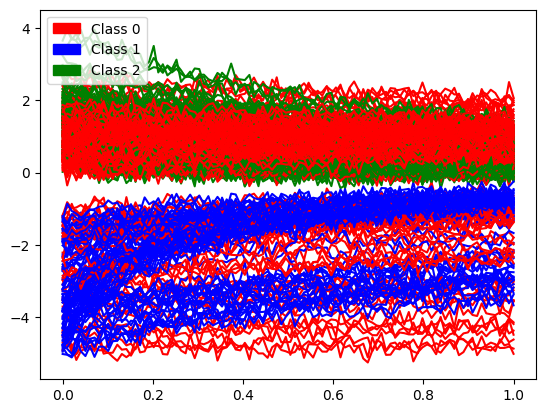

(145, 100)


In [50]:
from motion_code import MotionCode
from data_processing import load_data, process_data_for_motion_codes

np.random.seed(9)
name = 'logistic_ode'
x = np.linspace(0, 1, 100)
Y_train = np.zeros((400, 1, 100))
labels_train = np.zeros((400))
params = np.random.randn(20, 2) 
print(params)
Y_train_memo = []
threshold = 0.5

cnt = 0
for (lambda0, lambda1) in params:
    if lambda0 * lambda1 > 0:
        lower = 0.1
        upper = max(lambda1 / lambda0, 2)
    else:
        lower = min(-5, lambda0 / lambda1)
        upper = -1

    for g in np.random.uniform(lower, upper, 20):
        Y_train[cnt, 0, :] = u(x, lambda0=lambda0, lambda1=lambda1, u0=g)    
        
        delta = Y_train[cnt,0,-1] - Y_train[cnt, 0, 0]
        #delta = delta + f(1,Y_train[cnt,0,-1],lambda0=lambda0,lambda1=lambda1)
        if -threshold <= delta <= threshold:
            labels_train[cnt] = 0
        elif delta > threshold:
            labels_train[cnt] = 1
        else:
            labels_train[cnt] = 2
        
        Y_train_memo.append({'lambda0' : lambda0, 'lambda1': lambda1, 'u0': g, 'label': labels_train[cnt]})
        cnt = cnt + 1
Y_train = Y_train + np.random.normal(size=Y_train.shape) * 0.03 * np.max(np.abs(Y_train), axis=0)
labels_train = np.zeros((400))
# Then we process the data for motion code model and generate X-variable, which is needed for training.
X_train, Y_train, labels_train = process_data_for_motion_codes(Y_train, labels_train)


print(X_train.shape, Y_train.shape, labels_train.shape)
Y = Y_train[labels_train==2, :]
print(Y.shape)
color = ['red', 'blue', 'green']
for i in range(len(Y_train)):
    plt.plot(x, Y_train[i], color=color[labels_train[i]])

import matplotlib.patches as mpatches
handle_list, _ = plt.gca().get_legend_handles_labels()
handle_list.append(mpatches.Patch(color='red', label='Class 0'))
handle_list.append(mpatches.Patch(color='blue', label='Class 1'))
handle_list.append(mpatches.Patch(color='green', label='Class 2'))
plt.legend(handles=handle_list, fontsize='10', loc ="upper left")
plt.show()
print(Y.shape)


In [21]:
# Next we build the default motion code model forboth forecasting and classification
model = MotionCode(m=5, Q=2, latent_dim=2, sigma_y=0.01)

# Then we train model on the given X_train, Y_train, label_train set and saved it to a file named test_model.
model_path = 'saved_models/' + 'test_model_2'
model.fit(X_train, Y_train, labels_train, model_path)

[0.00470316 0.00409364 0.00359398 0.00319967 0.00290309 0.00269258
 0.00255263 0.00246577 0.00241511 0.00238656 0.00236988 0.00235884
 0.00235076 0.00234585 0.00234652 0.00235667 0.00238087 0.00242358
 0.00248835 0.00257717 0.00269015 0.00282554 0.00298    0.00314906
 0.00332756 0.00350999 0.0036908  0.00386455 0.00402605 0.00417037
 0.00429296 0.00438964 0.00445663 0.00449064 0.00448884 0.00444896
 0.00436939 0.00424924 0.00408853 0.00388844 0.00365167 0.00338312
 0.00309095 0.00278854 0.00249758 0.00225232 0.00210135 0.00209685
 0.00226643 0.00259597 0.00304701 0.00358089 0.00416757 0.00478482
 0.0054154  0.00604498 0.00666074 0.00725071 0.00780323 0.00830677
 0.00874974 0.00912049 0.00940723 0.00959806 0.00968105 0.00964424
 0.00947581 0.00916422 0.0086985  0.00806881 0.00726758 0.00629215
 0.00515232 0.00389638 0.00272433 0.00238087 0.00358452 0.00569768
 0.00828457 0.0112314  0.014508   0.01810728 0.02202986 0.02627916
 0.0308596  0.03577571 0.04103175 0.0466315  0.0525781  0.0588

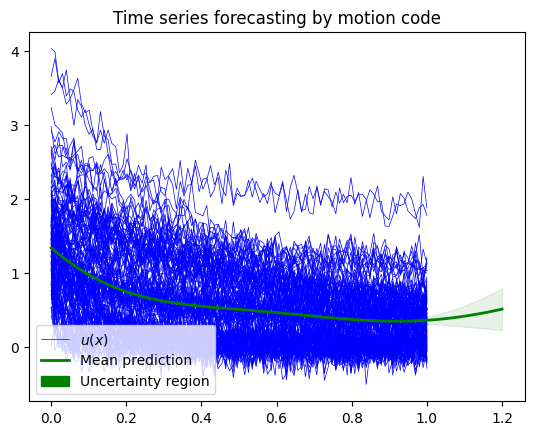

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

model.load(model_path)
# We predict on test time horizon [1, 1.2] with 20 time steps
test_time_horizon = np.linspace(0, 1.2, 100)

# label is the label for the stochastic process we predict
mean, covar = model.forecast_predict(test_time_horizon, label=2)
std = np.sqrt(np.diag(covar)).reshape(-1)
print(std)

# We plot all the time series on the horizon [0, 1]
X = X_train[labels_train==2, :]
Y = Y_train[labels_train==2, :]
plt.plot(X[0], Y[0], c='blue', lw=0.5, zorder=1, label='$u(x)$')
for i in range(1, X.shape[0]):
    plt.plot(X[i], Y[i], c='blue', lw=0.5, zorder=1)

# Then we plot our prediction with uncertainty on test time horizon = [1, 1.2]
plt.plot(test_time_horizon, mean, c='green', lw=2, zorder=1, label='Mean prediction')
plt.fill_between(test_time_horizon, mean+2*std, mean-2*std, color='green', alpha=0.1, zorder=1)

# Plot setting and plot show
handle_list, _ = plt.gca().get_legend_handles_labels()
handle_list.append(mpatches.Patch(color='green', label='Uncertainty region'))
plt.legend(handles=handle_list, fontsize='10', loc ="lower left")
#plt.ylim(1.1 * np.min(Y), 1.1 * np.max(Y))
plt.title('Time series forecasting by motion code')
plt.show()

[0.00468121 0.00407985 0.00358161 0.00318331 0.00287917 0.00265976
 0.00251185 0.00241966 0.00236713 0.00234009 0.00232749 0.00232177
 0.00231853 0.00231589 0.00231393 0.00231404 0.00231843 0.00232962
 0.00235    0.00238145 0.00242504 0.00248089 0.0025481  0.0026249
 0.00270878 0.00279676 0.00288554 0.00297176 0.00305209 0.00312338
 0.00318269 0.00322741 0.00325526 0.00326435 0.00325322 0.00322088
 0.00316692 0.00309154 0.00299573 0.00288142 0.00275173 0.00261136
 0.002467   0.00232793 0.00220638 0.00211735 0.00207706 0.00209946
 0.00219201 0.0023535  0.0025754  0.00284539 0.00315039 0.00347814
 0.00381766 0.00415908 0.0044934  0.00481219 0.00510739 0.00537115
 0.00559575 0.00577353 0.00589686 0.0059582  0.00595012 0.00586541
 0.0056973  0.0054398  0.00508843 0.00464158 0.00410377 0.00349363
 0.0028659  0.00236969 0.00231544 0.00293669 0.00410196 0.00562704
 0.00742515 0.00946337 0.01173038 0.01422381 0.01694523 0.01989804
 0.02308644 0.02651496 0.03018816 0.03411045 0.03828601 0.04271

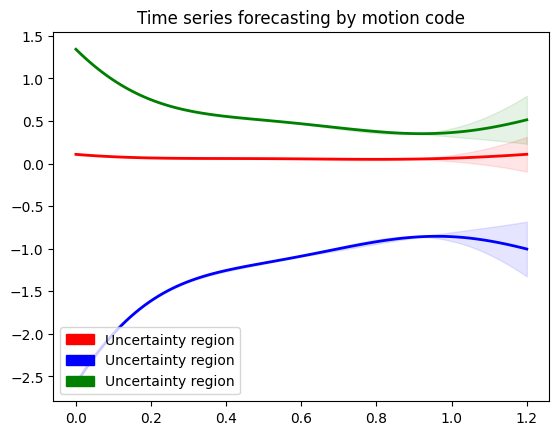

In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

model.load(model_path)
# We predict on test time horizon [1, 1.2] with 20 time steps
test_time_horizon = np.linspace(0, 1.2, 100)
# Plot setting and plot show
handle_list, _ = plt.gca().get_legend_handles_labels()
colors = ['red', 'blue', 'green']
for l in range(3):
    # label is the label for the stochastic process we predict
    mean, covar = model.forecast_predict(test_time_horizon, label=l)
    std = np.sqrt(np.diag(covar)).reshape(-1)
    print(std)
    color = colors[l]
    # Then we plot our prediction with uncertainty on test time horizon = [1, 1.2]
    plt.plot(test_time_horizon, mean, c=color, lw=2, zorder=1, label='Mean prediction')
    plt.fill_between(test_time_horizon, mean+2*std, mean-2*std, color=color, alpha=0.1, zorder=1)

    handle_list.append(mpatches.Patch(color=color, label='Uncertainty region'))
    plt.legend(handles=handle_list, fontsize='10', loc ="lower left")
    #plt.ylim(1.1 * np.min(Y), 1.1 * np.max(Y))
    plt.title('Time series forecasting by motion code')
plt.show()

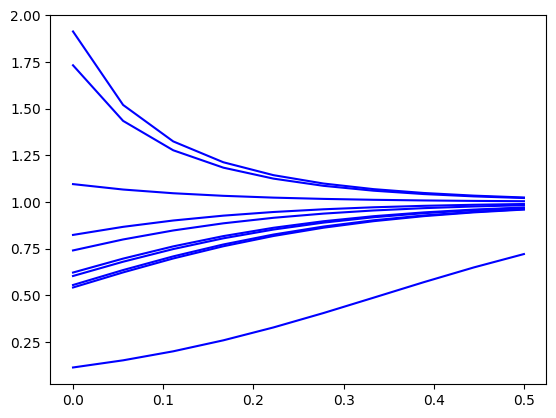

[0.54248031 1.09594836 0.8239367  0.55579765 0.62252358 0.60409333
 1.73213053 0.11425512 1.91313768 0.74094518]


In [43]:
Y_test = np.zeros((10, 1, 10))
np.random.seed(9999)
g_test = np.random.randn((10)) * 0.5 + 0.8
#g_test = np.append(g_test, [0.01])
x_test = np.linspace(0,1,10)
for i in range(len(g_test)):
    Y_test[i, 0, :] = u(x_test, u0=g_test[i])
labels_test = [0] * 10
X_test, Y_test, labels_test = process_data_for_motion_codes(Y_test, labels_test)
for i in range(len(g_test)):
    plt.plot(X_test[i], Y_test[i],c='blue')
plt.show()

print(g_test)

In [49]:
num_test = labels_test.shape[0]
predicted_labels = []
for ind in range(num_test):
    predicted_labels.append(model.classify_predict(X_test[ind], Y_test[ind], mode='variational'))
print('True label:', list(labels_test))
print('Predicted label:', predicted_labels)

TypeError: MotionCode.classify_predict() got an unexpected keyword argument 'mode'

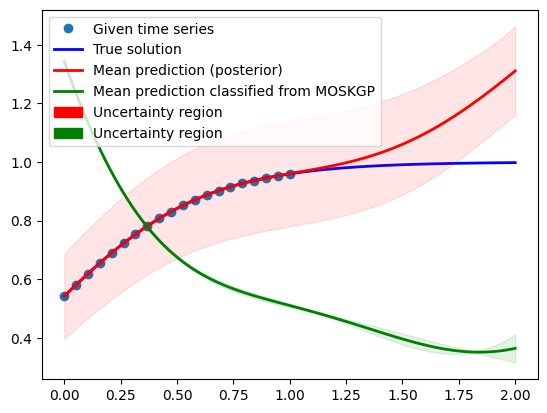

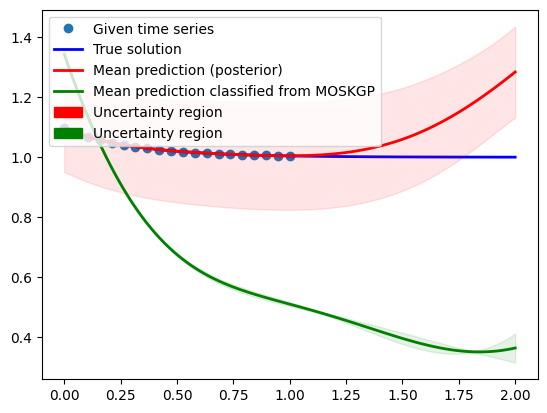

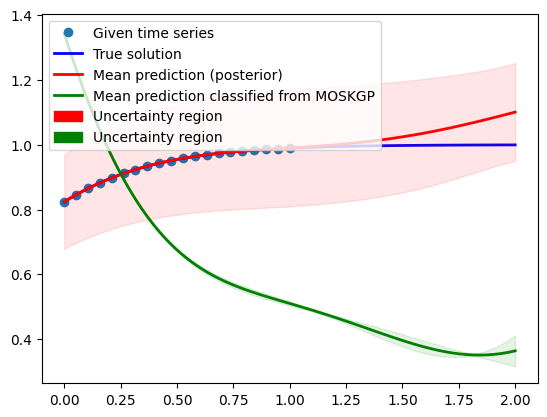

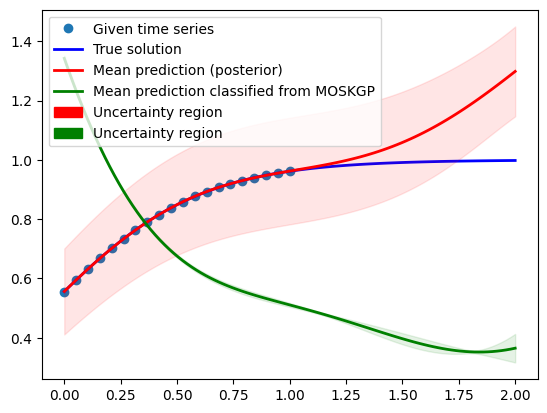

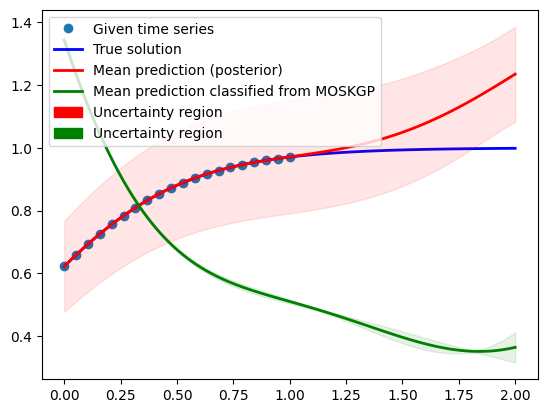

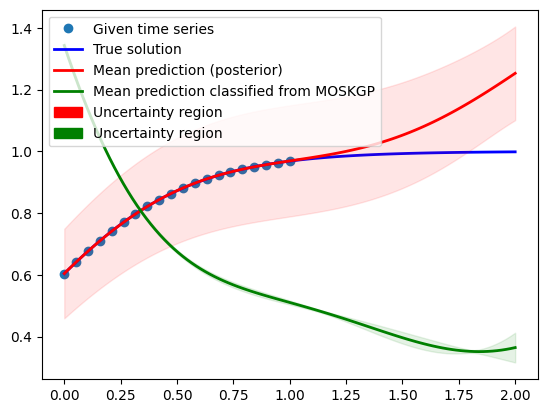

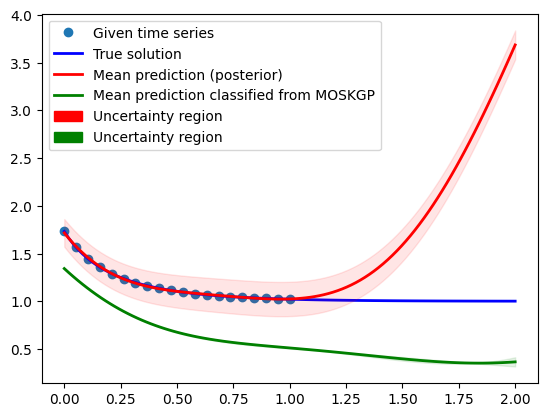

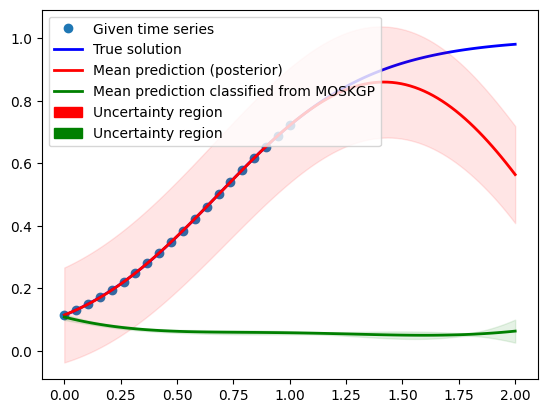

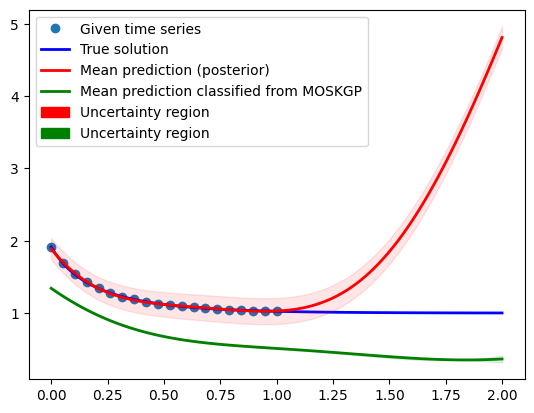

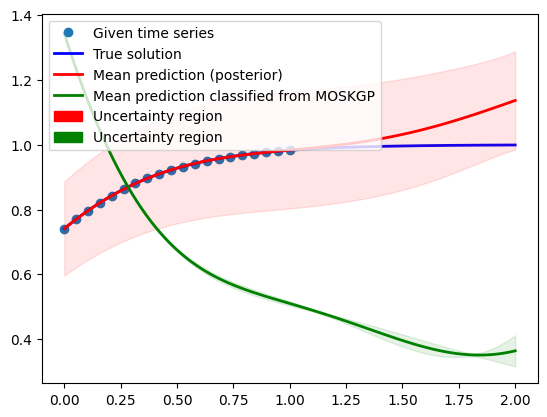

In [42]:
from sparse_gp import q, jitter, spectral_kernel, sigmoid


def qq(X_test, X_obs, Y_obs, X_m, kernel_params, mu_m, A_m, K_mm_inv):
    """
    Distribution prediction for a new collection of time variables
    """
    sigma, alpha = kernel_params
    K_ss = spectral_kernel(X_test, X_test, sigma, alpha)
    K_sm = spectral_kernel(X_test, X_m, sigma, alpha)
    K_ms = K_sm.T
    K_om = spectral_kernel(X_obs, X_m, sigma, alpha)
    K_mo = K_om.T
    K_os = spectral_kernel(X_obs, X_test, sigma, alpha)
    K_so = K_os.T
    K_oo = spectral_kernel(X_obs, X_obs, sigma, alpha) + jitter(X_obs.shape[0])
    K_oo_inv = np.linalg.inv(K_oo) 
    f_q = (K_so @ K_oo_inv).dot(Y_obs -  (K_om @ K_mm_inv).dot(mu_m)) + (K_sm @ K_mm_inv).dot(mu_m)
    # f_qq = (K_sm @ K_mm_inv).dot(mu_m)
    f_q_cov = K_ss - K_sm @ K_mm_inv @ K_ms + K_sm @ K_mm_inv @ A_m @ K_mm_inv @ K_ms \
        - K_so @ K_oo_inv @ K_os + K_so @ K_oo_inv @ (K_oo + 0.0001 * K_os @ K_so) @ K_oo_inv @ K_os 

    return f_q, f_q_cov

# redo the problem by recompute time stamps
x_test = np.linspace(0,2,100)
for ind in range(num_test):
    k = predicted_labels[ind]
    y = u(x_test, u0=g_test[ind])
    plt.plot(X_test[ind], Y_test[ind], 'o', lw=2, zorder=1, label='Given time series')
    plt.plot(x_test, y, color='blue', lw=2, zorder=1, label='True solution')
    
    mean, covar = qq(x_test, X_test[ind], Y_test[ind], sigmoid(model.X_m @ model.Z[k]), model.kernel_params[k], model.mu_ms[k], model.A_ms[k], model.K_mm_invs[k])
    std = np.sqrt(np.diag(covar)).reshape(-1)
    plt.plot(x_test, mean, c='red', lw=2, zorder=1, label='Mean prediction (posterior)')
    plt.fill_between(x_test, mean+2*std, mean-2*std, color='red', alpha=0.1, zorder=1)
    mean, covar = q(x_test, sigmoid(model.X_m @ model.Z[k]), model.kernel_params[k], model.mu_ms[k], model.A_ms[k], model.K_mm_invs[k])
    std = np.sqrt(np.diag(covar)).reshape(-1)
    plt.plot(x_test, mean, c='green', lw=2, zorder=1, label='Mean prediction classified from MOSKGP')
    plt.fill_between(x_test, mean+2*std, mean-2*std, color='green', alpha=0.1, zorder=1)
    # Plot setting and plot show
    handle_list, _ = plt.gca().get_legend_handles_labels()
    handle_list.append(mpatches.Patch(color='red', label='Uncertainty region'))
    handle_list.append(mpatches.Patch(color='green', label='Uncertainty region'))
    plt.legend(handles=handle_list, fontsize='10', loc ="upper left")
    plt.show()

In [48]:
mse = []
stds = []
x= np.linspace(1,2,100)
for ind in range(num_test):
    k = predicted_labels[ind]
    y_gt =  u(x, u0=g_test[ind])
    y, covar = qq(x, X_test[ind], Y_test[ind], sigmoid(model.X_m @ model.Z[k]), model.kernel_params[k], model.mu_ms[k], model.A_ms[k], model.K_mm_invs[k])
    mse.append(np.mean((y-y_gt)**2))
    std = np.sqrt(np.diag(covar)).reshape(-1)
    stds.append(np.mean(std))
print(np.mean(mse), np.mean(std))

7.969244405251343 0.46530060583752425


In [2]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from jax import jit, value_and_grad
import numpy as np


jax.config.update("jax_enable_x64", True)

@jit
def similarity_score_between_gps(mu_1, mu_2, Sigma_1, Sigma_2):
    mu_norm = jnp.linalg.norm(mu_1-mu_2)
    U, D, VT = jax.lax.linalg.svd(Sigma_1, full_matrices=False)
    jax.debug.print("U-V:{}", jnp.linalg.norm(U-VT.T))
    Sigma_1_half = U @ jnp.diag(jnp.sqrt(D)) @ VT
    UU, DD, VVT = jax.lax.linalg.svd(Sigma_1_half @ Sigma_2 @ Sigma_1_half, full_matrices=False)
    cov_diff = Sigma_1 + Sigma_2 - 2 * UU @ jnp.diag(jnp.sqrt(DD)) @ VVT
    return jnp.sqrt(mu_norm ** 2 + jnp.trace(cov_diff))

@jit
def safe_symmetric_matrix_inv(B):
    """
        Use cholesky factorization to safely inverse a symmetric matrix
    """ 
    L = jsp.linalg.cho_factor(B)
    Ainv = jsp.linalg.cho_solve(L, jnp.eye(B.shape[0]))
    return Ainv

#grad = jax.grad(similarity_score_between_gps)

mu_1 = np.random.randn((100))
mu_2 = np.random.randn((100))
A = np.random.rand(100, 100)
Sigma_1 = np.dot(A, A.transpose())
A = np.random.rand(100, 100)
Sigma_2 = np.dot(A, A.transpose())
#print(Sigma_1)

Sigma_1_inv = safe_symmetric_matrix_inv(Sigma_1)

print(np.sum((Sigma_1_inv @ Sigma_1 - np.eye(100))** 2))

#print(grad(mu_1,mu_2,Sigma_1,Sigma_2))

print(similarity_score_between_gps(mu_1,mu_2,Sigma_1,Sigma_2))

3.083660211809325e-19
U-V:3.579666725618464e-12
25.797062503926195
